## Food recommendation based on grouping of foods with similar nutrient contents
Selected model = k-prototypes - cluster both numerical and categorical data

In [1]:
# libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes

proj_dir = "D:/r/KenyaDSM"
foods_path = proj_dir + '/' + "data/foods"

### Prepare data

In [2]:
foods = pd.read_csv(foods_path + '/' + 'veg_k_mg.csv')
foods.tail()

,Code,Vegetable,Magnesium,Potassium
91,4097,"Tomato, green, boiled, drained (without salt)",10.0,144.0
92,4036,"Tomato, red, ripe, raw",9.5,126.0
93,4098,"Tomato, red, ripe, boiled, drained (without salt)",7.0,81.0
94,4038,"Vine (African) spinach, picked leaves, raw",40.0,446.0
95,4099,"Vine (African) spinach, picked leaves, boiled,...",25.0,234.0


In [3]:
# convert datatypes - code
foods.dtypes

Code           int64
Vegetable     object
Magnesium    float64
Potassium    float64
dtype: object

In [4]:
foods["Code"] = foods["Code"].astype(str)
foods.dtypes

Code          object
Vegetable     object
Magnesium    float64
Potassium    float64
dtype: object

<Axes: xlabel='Magnesium', ylabel='Potassium'>

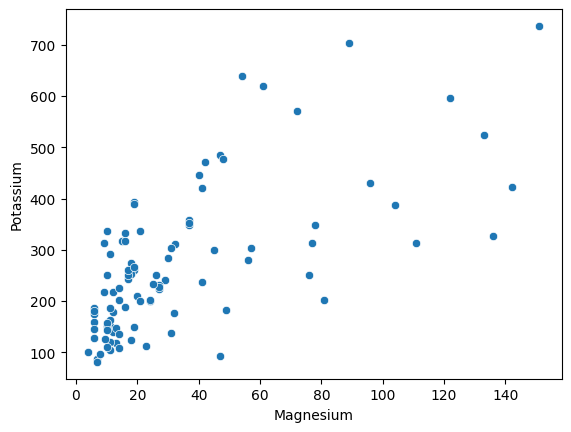

In [5]:
# visualise distribution
sns.scatterplot(data=foods, x='Magnesium', y='Potassium')

many foods have both relatively low mg and potassium values. select clusters with low, medium and high vals (low might have highest number of foods)

In [6]:
# normalise nutrient values
scaler = StandardScaler()
nut_cols = list(foods.dtypes[foods.dtypes != 'object'].index)
foods.loc[:, nut_cols] = scaler.fit_transform(foods.loc[:, nut_cols])
foods

,Code,Vegetable,Magnesium,Potassium
0,4001,"Amaranth, leaves, picked, raw",2.615876,2.330648
1,4039,"Amaranth, leaves, picked, boiled, drained (wit...",1.279828,0.329593
2,4040,"Amaranth, leaves, picked, stewed (without salt)",3.476884,3.320569
3,4002,"Bitter gourd, whole, different varieties, raw",-0.412499,-0.405777
4,4041,"Bitter gourd, whole, different varieties, boil...",-0.620329,-1.063368
...,...,...,...,...
91,4097,"Tomato, green, boiled, drained (without salt)",-0.709399,-0.872454
92,4036,"Tomato, red, ripe, raw",-0.724244,-0.999730
93,4098,"Tomato, red, ripe, boiled, drained (without salt)",-0.798469,-1.317919
94,4038,"Vine (African) spinach, picked leaves, raw",0.181300,1.262947


### K-Prototypes Modelling

- cluster with elbow analysis to determine suitable number of clusters

In [7]:
# convert to array
foods_arr = np.array(foods)
type(foods_arr)

numpy.ndarray

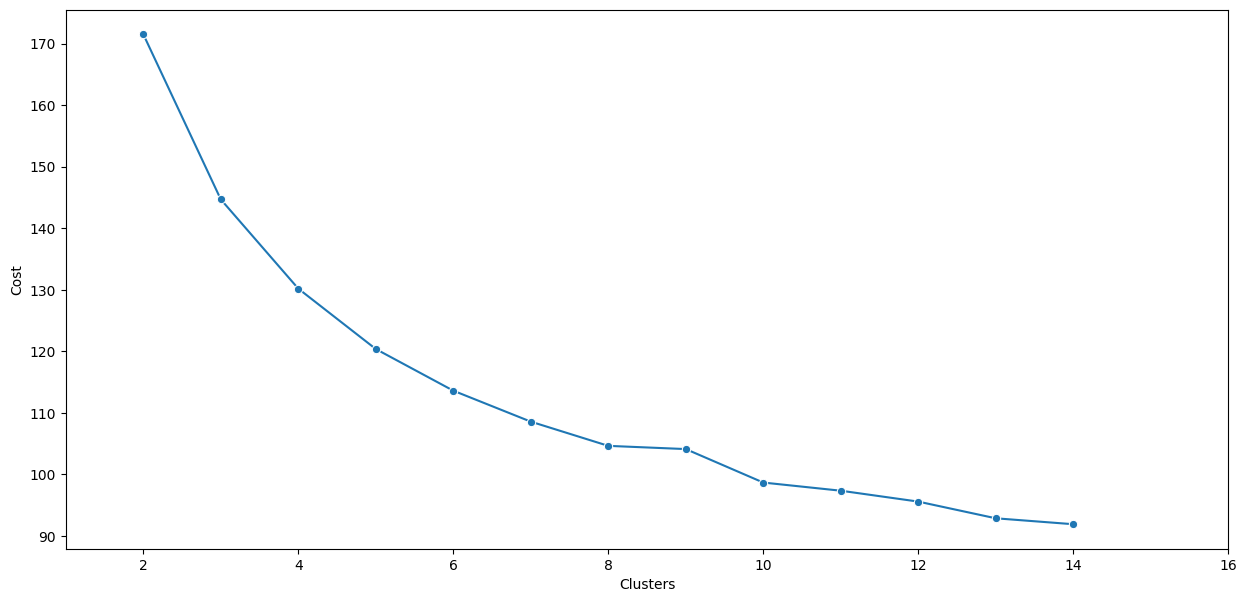

In [8]:
clusters = list(range(2,15)) # test clusters from 2 to 10
costs = []

for k in clusters:
    kp = KPrototypes(n_clusters=k, init='Huang', random_state=42)
    kp.fit(foods_arr, categorical=[0,1])
    costs.append(kp.cost_)

# elbow plot
plt.figure(figsize=(15,7))
ax = sns.lineplot(x=clusters, y=costs, marker="o", dashes=False)
ax.set_xlabel('Clusters')
ax.set_ylabel('Cost')
ax.set(xlim=(1,16))
plt.plot();

-settled on 9 clusters. remodel with 9 clusters and set to food data

In [9]:
kp = KPrototypes(n_clusters=9, init='Huang', random_state=42)
kp.fit(foods_arr, categorical=[0,1])
foods['Category'] = kp.labels_
foods

,Code,Vegetable,Magnesium,Potassium,Category
0,4001,"Amaranth, leaves, picked, raw",2.615876,2.330648,2
1,4039,"Amaranth, leaves, picked, boiled, drained (wit...",1.279828,0.329593,0
2,4040,"Amaranth, leaves, picked, stewed (without salt)",3.476884,3.320569,2
3,4002,"Bitter gourd, whole, different varieties, raw",-0.412499,-0.405777,1
4,4041,"Bitter gourd, whole, different varieties, boil...",-0.620329,-1.063368,3
...,...,...,...,...,...
91,4097,"Tomato, green, boiled, drained (without salt)",-0.709399,-0.872454,3
92,4036,"Tomato, red, ripe, raw",-0.724244,-0.999730,3
93,4098,"Tomato, red, ripe, boiled, drained (without salt)",-0.798469,-1.317919,3
94,4038,"Vine (African) spinach, picked leaves, raw",0.181300,1.262947,7


In [10]:
# retransform scaled values
foods.loc[:, nut_cols] = scaler.inverse_transform(foods.loc[:, nut_cols])
foods

,Code,Vegetable,Magnesium,Potassium,Category
0,4001,"Amaranth, leaves, picked, raw",122.0,597.0,2
1,4039,"Amaranth, leaves, picked, boiled, drained (wit...",77.0,314.0,0
2,4040,"Amaranth, leaves, picked, stewed (without salt)",151.0,737.0,2
3,4002,"Bitter gourd, whole, different varieties, raw",20.0,210.0,1
4,4041,"Bitter gourd, whole, different varieties, boil...",13.0,117.0,3
...,...,...,...,...,...
91,4097,"Tomato, green, boiled, drained (without salt)",10.0,144.0,3
92,4036,"Tomato, red, ripe, raw",9.5,126.0,3
93,4098,"Tomato, red, ripe, boiled, drained (without salt)",7.0,81.0,3
94,4038,"Vine (African) spinach, picked leaves, raw",40.0,446.0,7


#### Visualise clusters

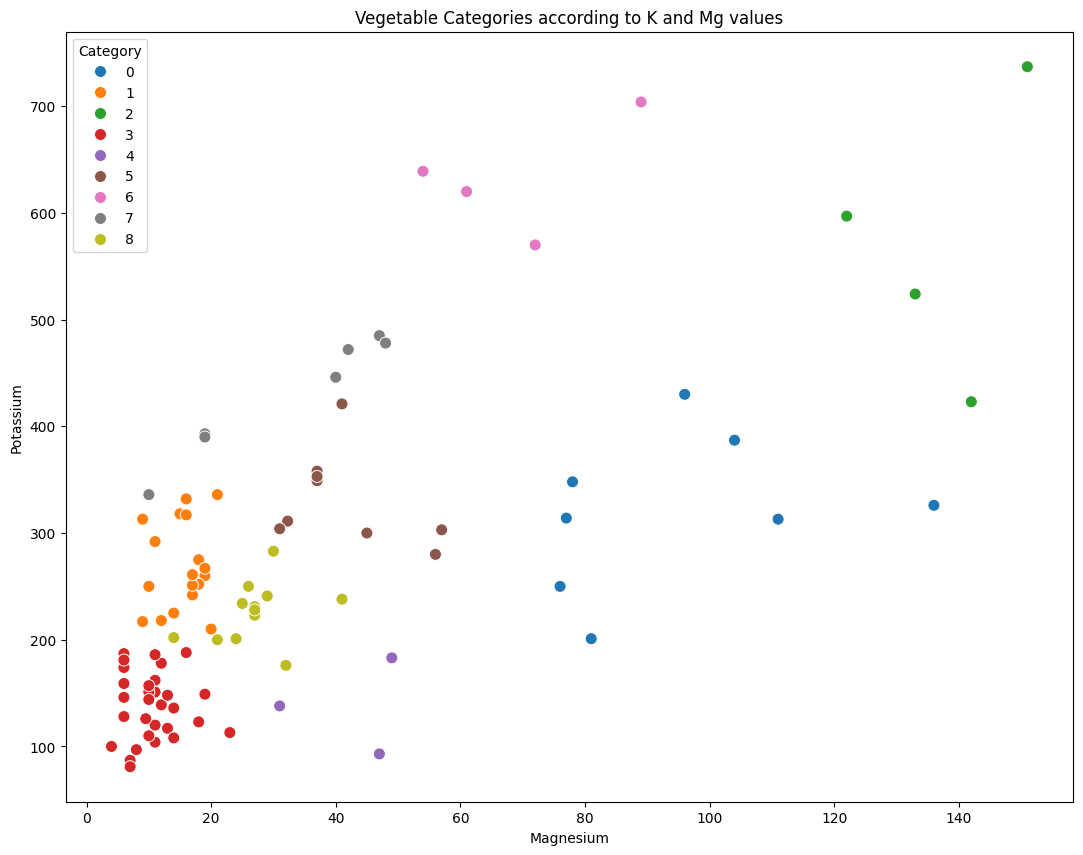

In [17]:
plt.figure(figsize=(13,10))
sns.scatterplot(data=foods, x='Magnesium', y='Potassium', hue='Category', palette="tab10", s=75)
plt.title("Vegetable Categories according to K and Mg values")
plt.legend(title='Category')
plt.show()

In [19]:
# export to csv for use in DB
foods.to_csv(foods_path + '/' + 'cat_veg.csv')